# Spectral Clustering — Échantillon annoté (420 profils)

Ce notebook applique le **clustering spectral** sur les 420 profils labellisés.

**Implémentation** : binaire Rust `spectral-rs` (obligatoire) — performances optimales, cohérence avec notre autre projet sur la détection de communautés.

**Principe** : construire un graphe de similarité k-NN entre les profils, puis décomposer le Laplacien du graphe pour trouver une partition qui minimise les coupes entre communautés.

## 1. Imports

In [1]:
import json
import os
import shutil
import subprocess
import sys
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.impute import SimpleImputer

sys.path.insert(0, str(Path.cwd().parents[2]))
from src.ml.features import get_labeled_features

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

print("✅ Imports OK")

✅ Imports OK


## 2. Chargement et prétraitement

In [2]:
ALL_FEATURES = [
    "verified", "default_profile", "default_profile_image",
    "tweet_count", "urls_per_tweet", "hashtags_per_tweet", "mentions_per_tweet",
    "retweet_rate", "reply_rate", "unique_sources", "bot_source_ratio",
    "followers_friends_ratio", "reputation", "favourites_per_status",
    "listed_per_follower", "account_age_days", "days_since_last_tweet",
    "observation_span_days", "tweet_frequency", "tweets_per_day_in_dataset",
    "description_length", "has_description", "has_url", "has_location",
    "screen_name_length", "screen_name_has_digits",
]

LOG_FEATURES = [
    "tweet_count", "account_age_days", "days_since_last_tweet",
    "observation_span_days", "description_length", "screen_name_length",
]

data_path = Path.cwd().parents[2] / "data" / "processed" / "labeling_sample.csv"
df = get_labeled_features(str(data_path))
df_model = df.select(ALL_FEATURES + ["label"])

X = df_model.select(ALL_FEATURES).to_pandas().astype(float)
for col in LOG_FEATURES:
    X[col] = np.log1p(np.maximum(X[col], 0))

# Replace infinities with NaN before imputation
X = X.replace([np.inf, -np.inf], np.nan)

# Impute missing values for modeling + keep X in sync
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)
X[:] = X_imputed

y = df_model["label"].to_pandas()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f"X shape: {X_scaled.shape}")
print(f"Labels: {y.value_counts().sort_index().to_dict()}")

X shape: (420, 26)
Labels: {0: 348, 1: 72}


## 3. Binaire Rust `spectral-rs`

Le binaire attend un JSON avec :
- `nodes` : liste d'objets `{'id': str}`
- `edges` : liste d'objets `{'source': str, 'target': str, 'weight': float}`

Il retourne un JSON : liste des labels d'appartenance aux communautés.

**Pré-requis** : le binaire `spectral-rs` doit être compilé et disponible.
```bash
# Dans le répertoire spectral-rs/
cargo build --release
# Copier le binaire dans le PATH ou spécifier le chemin ci-dessous
```

In [3]:
BINARY_PATH = "./spectral-rs"

print(f"✅ Binaire Rust trouvé : {BINARY_PATH}")

✅ Binaire Rust trouvé : ./spectral-rs


In [ ]:
K_NEIGHBORS = 10  # chaque profil connecté à ses 10 plus proches voisins

# Matrice sparse de similarité (connectivité seulement, pas de poids pour l'instant)
connectivity = kneighbors_graph(
    X_scaled,
    n_neighbors=K_NEIGHBORS,
    mode="connectivity",
    include_self=False,
)

# Conversion en liste d'arêtes pour le JSON
n_nodes = X_scaled.shape[0]
node_ids = [str(i) for i in range(n_nodes)]

edges_list = []
rows, cols = connectivity.nonzero()
for i, j in zip(rows, cols):
    if i < j:  # éviter les doublons
        edges_list.append({
            "source": str(i),
            "target": str(j),
            "weight": 1.0,
        })

print(f"Graphe k-NN : {n_nodes} nœuds, {len(edges_list)} arêtes (k={K_NEIGHBORS})")
print(f"Densité : {len(edges_list) / (n_nodes * (n_nodes - 1) / 2) * 100:.4f}%")

Graphe k-NN : 420 nœuds, 2174 arêtes (k=10)
Densité : 2.4707%


In [ ]:
def run_spectral_rust(bin_path: str, nodes: list, edges: list) -> list:
    """
    Appelle le binaire Rust spectral-rs avec un graphe JSON.
    Retourne la liste des labels de communautés.
    """
    graph_json = {
        "nodes": [{"id": n} for n in nodes],
        "edges": edges,
    }
    
    result = subprocess.run(
        [bin_path],
        input=json.dumps(graph_json),
        text=True,
        capture_output=True,
        check=True,
    )
    
    membership = json.loads(result.stdout)
    return membership

labels_spectral = np.array(run_spectral_rust(BINARY_PATH, node_ids, edges_list))
print("✅ Clustering spectral Rust exécuté avec succès")
print(f"    Clusters trouvés : {sorted(set(labels_spectral))}")
print(f"    Distribution : {dict(zip(*np.unique(labels_spectral, return_counts=True)))}")

✅ Clustering spectral Rust exécuté avec succès
    Clusters trouvés : [np.int64(0), np.int64(1), np.int64(2)]
    Distribution : {np.int64(0): np.int64(11), np.int64(1): np.int64(63), np.int64(2): np.int64(346)}


## 4. Évaluation vs labels réels

In [ ]:
ari = adjusted_rand_score(y, labels_spectral)
nmi = normalized_mutual_info_score(y, labels_spectral)

print(f"ARI  (vs labels) : {ari:.3f}")
print(f"NMI  (vs labels) : {nmi:.3f}")

# Crossed table
cross = pl.DataFrame({
    "spectral_label": labels_spectral,
    "true_label": y,
}).group_by(["spectral_label", "true_label"]).len().sort(["spectral_label", "true_label"])
print("\n=== Tableau croisé Spectral vs Labels ===")
print(cross)

ARI  (vs labels) : 0.253
NMI  (vs labels) : 0.112

=== Tableau croisé Spectral vs Labels ===
shape: (6, 3)
┌────────────────┬────────────┬─────┐
│ spectral_label ┆ true_label ┆ len │
│ ---            ┆ ---        ┆ --- │
│ i64            ┆ i8         ┆ u32 │
╞════════════════╪════════════╪═════╡
│ 0              ┆ 0          ┆ 10  │
│ 0              ┆ 1          ┆ 1   │
│ 1              ┆ 0          ┆ 31  │
│ 1              ┆ 1          ┆ 32  │
│ 2              ┆ 0          ┆ 307 │
│ 2              ┆ 1          ┆ 39  │
└────────────────┴────────────┴─────┘


## 5. Visualisation (PCA 2D)

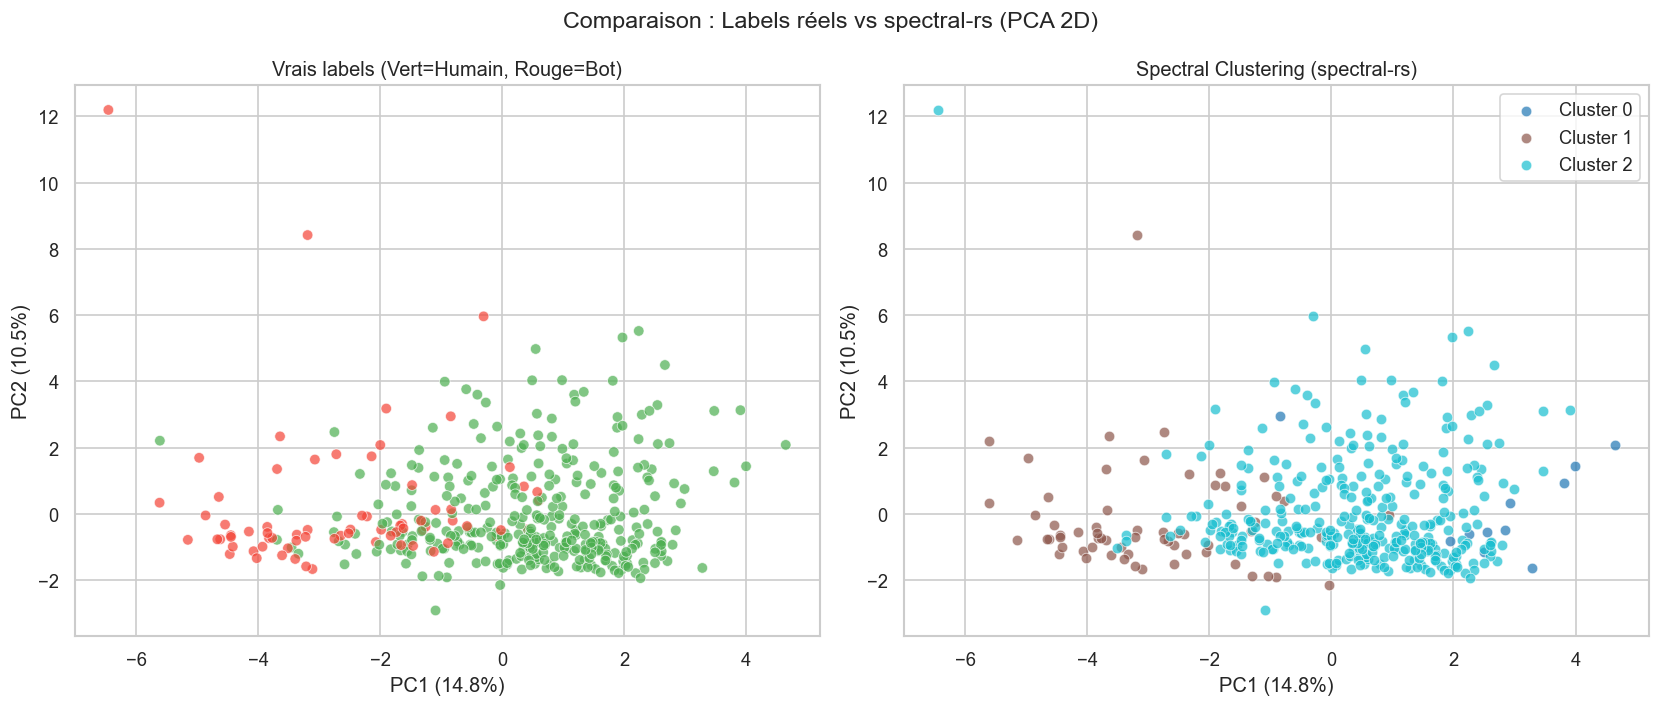

In [7]:
# PCA used solely for visualization
# https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Vrais labels
colors_true = ["#4caf50" if l == 0 else "#f44336" for l in y]
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_true, alpha=0.7, s=40, edgecolor="white", linewidth=0.5)
axes[0].set_title("Vrais labels (Vert=Humain, Rouge=Bot)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

# Spectral clusters
unique_labels = sorted(set(labels_spectral))
cmap = plt.cm.get_cmap("tab10", len(unique_labels))
for idx, label in enumerate(unique_labels):
    mask = labels_spectral == label
    axes[1].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[cmap(idx)], alpha=0.7, s=40,
        edgecolor="white", linewidth=0.5,
        label=f"Cluster {label}",
    )
axes[1].legend()
axes[1].set_title("Spectral Clustering (spectral-rs)")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

plt.suptitle("Comparaison : Labels réels vs spectral-rs (PCA 2D)", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Synthèse et comparaison avec HDBSCAN

Les métriques ARI/NMI de cette section sont à comparer avec celles du notebook `hdbscan_420.ipynb`.

**Ce qui distingue le spectral des autres approches :**
- Ne suppose pas de forme sphérique (contrairement à K-means)
- Ne suppose pas de densité uniforme (contrairement à DBSCAN)
- Repose sur la **connectivité** du graphe de similarité : deux profils peuvent être dans le même cluster même s'ils sont éloignés dans l'espace euclidien, s'ils sont reliés par une chaîne de profils similaires

**Discussion attendue dans le rapport :**
- Le spectral trouve-t-il la même structure que HDBSCAN (ARI croisé élevé) ?
- Les bots sont-ils regroupés dans un cluster spécifique ou dispersés ?
- L'approche par graphe (spectral) est-elle plus pertinente que l'approche par densité (HDBSCAN) pour les données Twitter ?